<a href="https://colab.research.google.com/github/c-marq/CAP3321C-Data-Wrangling/blob/main/[PATH]/case-study-medical-starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Costs Case Study: Section 1

**CAP3321C Data Wrangling** | Group lab | Miami Dade College

**Scenario.** You are an analyst employed by a health care company. Your boss has asked you to produce a report that answers five questions about medical insurance charges.

**How this notebook works.** The setup cell loads the data. After that, every question has three cells: a heading, a code cell for your analysis, and a markdown cell where you write what the table or plot tells you. Your boss reads the markdown, not the code. Keep this notebook clean; you will extend it for your final (section 2 of this case study).

**Notebook requirements**
- A markdown heading for every question
- A table or plot that answers it
- A short written summary under each answer
- Comments or markdown explaining any cleaning decision and any code that is not obvious

**Group Members:**
- Name 1: Muhammad Tauseef
- Name 2: Ashley Howard
- Name 3: Kristian Cardenas
- Name 4: Lucas Snook

**Roles:** Lead Coder / Data Interpreter / Presenter / QA Reviewer

## Setup

In [2]:
# Run this cell. Do not modify.
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/c-marq/CAP3321C-Data-Wrangling/main/data/insurance.csv"
insurance_df = pd.read_csv(url)

print(insurance_df.shape)
insurance_df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


**Checkpoint.** The shape should be `(1338, 7)`. If it is not, re-run the setup cell.

## Explore and clean the data

Before answering anything, get to know the file. Use `info()`, `describe()`, `isna().sum()`, and `value_counts()` on the columns you plan to use. Then make your cleaning decisions and **explain them in the markdown cell below the code**.

In [3]:
# Explore: run info(), describe(), isna().sum(), and value_counts() on the columns you care about
# YOUR CODE HERE
insurance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
insurance_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
insurance_df.value_counts()

age  children  region     charges    
19   0         northwest  1639.56310     2
48   0         southeast  7789.63500     1
               northwest  8671.19125     1
47   4         northeast  10407.08585    1
     3         southwest  25309.48900    1
                                        ..
30   3         southwest  18259.21600    1
                          5325.65100     1
               southeast  40932.42950    1
                          4837.58230     1
31   0         southwest  3260.19900     1
Name: count, Length: 1337, dtype: int64

In [13]:
# Clean: apply any changes you decided on (drop rows, fix types, filter categories)
# YOUR CODE HERE

insurance_df = insurance_df.drop(columns=['sex', 'bmi', 'smoker'], errors='ignore')
display(insurance_df.head())

,age,children,region,charges
0,19,0,southwest,16884.92400
1,18,1,southeast,1725.55230
2,28,3,southeast,4449.46200
3,33,0,northwest,21984.47061
4,32,0,northwest,3866.85520


In [14]:
insurance_df.nunique()

,0
age,47
children,6
region,4
charges,1337


In [15]:
insurance_df.groupby('region').nunique()

,age,children,charges
region,,,
northeast,46,6,324
northwest,46,6,324
southeast,47,6,364
southwest,46,6,325


In [16]:
insurance_df_original = pd.read_csv(url)
print("Unique values in 'sex':", insurance_df_original['sex'].unique())
print("Unique values in 'smoker':", insurance_df_original['smoker'].unique())
print("Unique values in 'region':", insurance_df_original['region'].unique())

Unique values in 'sex': ['female' 'male']
Unique values in 'smoker': ['yes' 'no']
Unique values in 'region': ['southwest' 'southeast' 'northwest' 'northeast']


**Things to look at in this dataset**
- Run `info()` and `isna().sum()`. This file is clean. Say so in a markdown cell; "we checked and found nothing to fix" is a valid cleaning step.
- Look at the unique values of `sex`, `smoker`, and `region` to confirm there are no typos or capitalization mismatches.

**Our cleaning decisions and why:**

(write here)

## Question 1: How is age related to medical costs?

*Hint: Two numeric columns. A scatter plot shows the relationship; think about what pattern you see and what might explain the separate bands.*

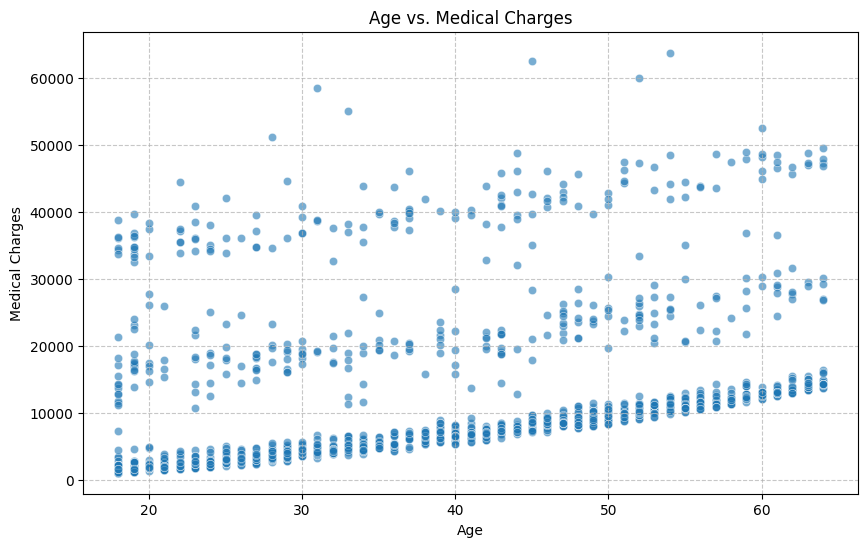

In [20]:
# Question 1
# Your code here

plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=insurance_df, alpha=0.6)
plt.title('Age vs. Medical Charges')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Summary for Question 1:**

The baseline charges steadily increase as age increses. The Scatterplot also illustrates that Charges tend to Fall into one of three tiers. These Tiers suggest there may be other factors that influence the charges.

## Question 2: How is number of children related to medical costs?

*Hint: `children` is a small whole number, so group by it and compare the average charges. A bar chart works well here.*

/tmp/ipykernel_778/2771987206.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='children', y='charges', data=average_charges_by_children, palette='viridis')


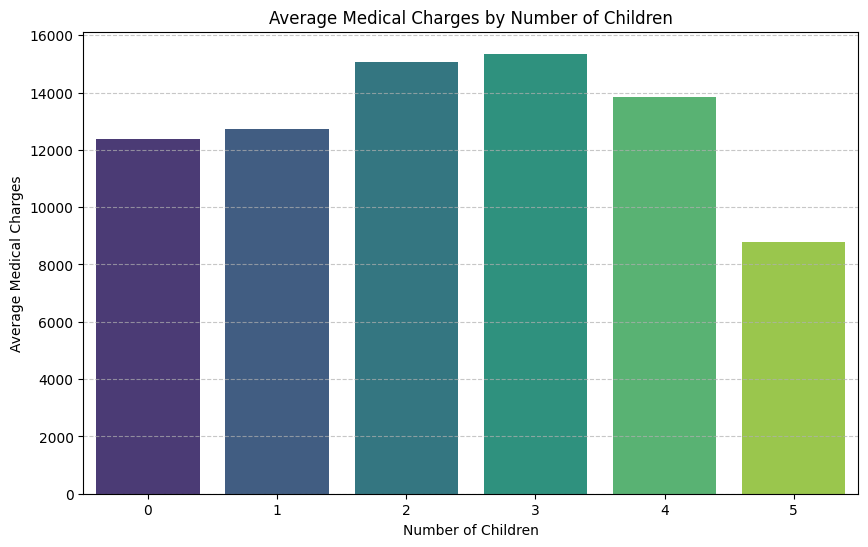

In [21]:
# Question 2
# YOUR CODE HERE

import matplotlib.pyplot as plt
import seaborn as sns

average_charges_by_children = insurance_df.groupby('children')['charges'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='children', y='charges', data=average_charges_by_children, palette='viridis')
plt.title('Average Medical Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Medical Charges')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Summary for Question 2:**

The bar chart indicates that average medical charges are relatively similar for individuals with 0, 1, 2, or 3 children, peaking slightly for those with 2 and 3 children. Interestingly, there's a decrease in average charges for individuals with 4 children, and the lowest average charges are observed for those with 5 children. This suggests that while there might be a slight increase in charges up to three children, a higher number of dependents does not necessarily correlate with continually increasing medical costs, and can even be associated with lower averages. Our group also did some extra bar charts to figure it out but still no results.

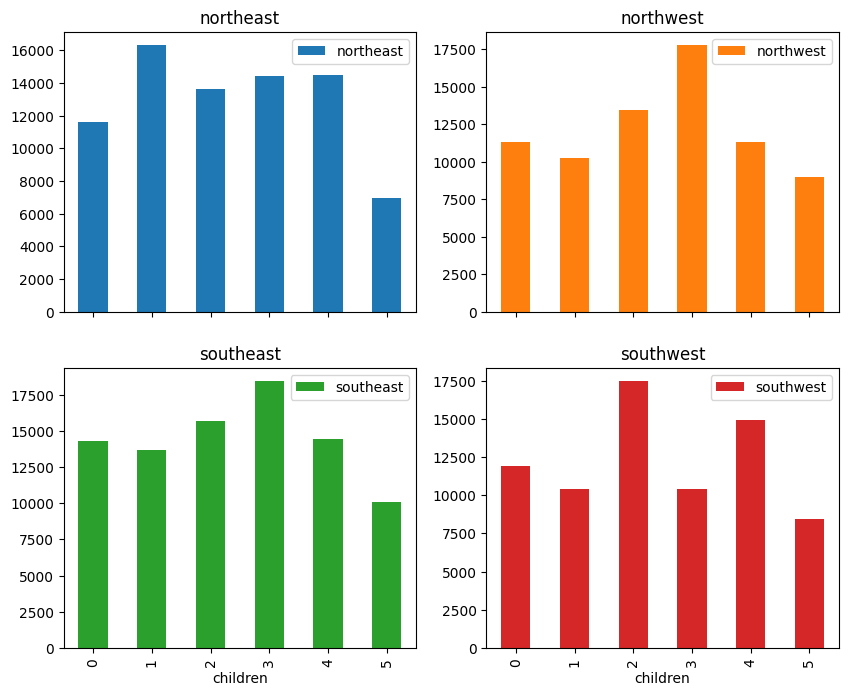

In [23]:
insurance_df.groupby(
    ['region', 'children']
)['charges'].mean().unstack(level=0).plot(
    kind='bar',
    subplots=True,
    layout=(2, 2),
    figsize=(10, 8)
)
plt.show()

## Question 3: How is the number of people distributed by region?

*Hint: One column, one `value_counts()`. Table or bar chart.*

/tmp/ipykernel_778/3784466546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='count', data=region_counts, palette='Paired')


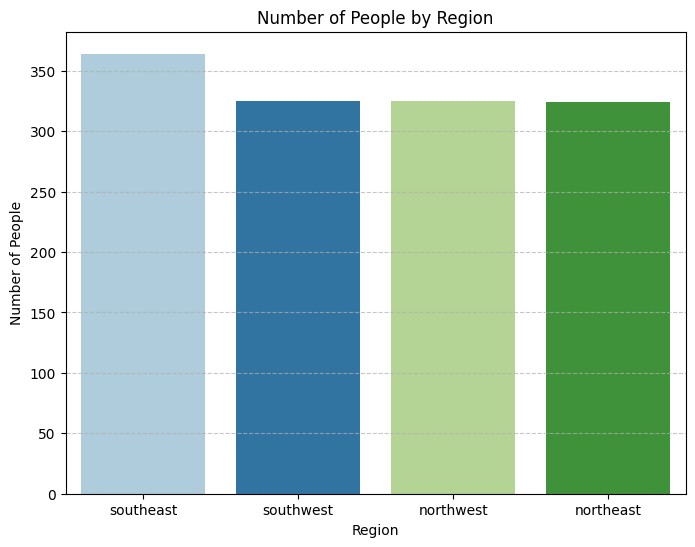

In [22]:
# Question 3
# YOUR CODE HERE

region_counts = insurance_df['region'].value_counts().reset_index()
region_counts.columns = ['region', 'count']

plt.figure(figsize=(8, 6))
sns.barplot(x='region', y='count', data=region_counts, palette='Paired')
plt.title('Number of People by Region')
plt.xlabel('Region')
plt.ylabel('Number of People')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Summary for Question 3:**

The number of people is relatively evenly distributed across all four regions. The Southeast region has the largest representation with 364 people, while the Southwest, Northwest, and Northeast regions have approximately 324–325 people each. This balanced distribution means no single region dominates the dataset

## Question 4: How is the number of people distributed by age?

*Hint: A histogram of the age column. Pick a sensible number of bins and comment on the shape.*

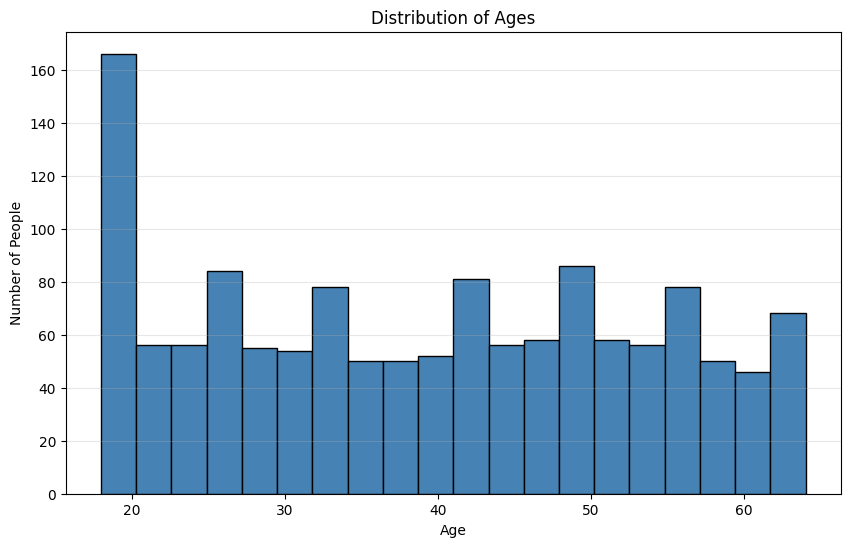

In [25]:
# Question 4
# YOUR CODE HERE

plt.figure(figsize=(10, 6))
plt.hist(insurance_df['age'], bins=20, color='steelblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.title('Distribution of Ages')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

**Summary for Question 4:**

The histogram displaying the distribution of ages shows a prominent bar for individuals aged 18-19, indicating a large number of participants in this younger age bracket. After this initial peak, the distribution of ages appears more varied, with several smaller peaks and dips across the remaining age range. This suggests that while there is a strong presence of young adults, other age groups are also represented, though not in a perfectly uniform manner. The distribution is somewhat spread out from the early 20s to the mid-60s, without a clear single central tendency after the initial youth surge.

## Question 5: How are the charges distributed?

*Hint: A histogram of charges. Describe the shape and note where the long tail comes from.*

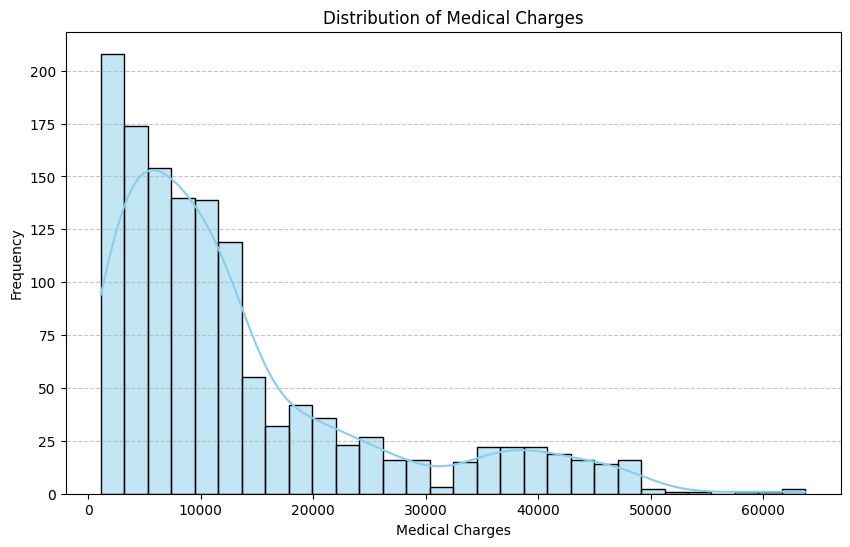

In [27]:
# Question 5
# YOUR CODE HERE

plt.figure(figsize=(10, 6))
sns.histplot(insurance_df['charges'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Medical Charges')
plt.xlabel('Medical Charges')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Summary for Question 5:**

The histogram of medical charges shows a heavily right-skewed distribution. The majority of individuals incur lower medical costs, with a high frequency of charges concentrated at the lower end of the spectrum (below approximately $10,000).

As the charge amount increases, the frequency of individuals decreases sharply, forming a 'long tail' that extends towards very high medical expenses (up to $60,000 or more). This long tail suggests that while most people have relatively low costs, a smaller group of individuals accounts for significantly higher medical charges, which could be due to serious illnesses, chronic conditions, or extensive treatments.

## Share-out

Pick the one question your group found most interesting or most surprising. The Presenter will show that table or plot and explain it in under three minutes.

**Question we are presenting:** Question 2

**Why:** Our Group found the distribution of charges by number of children to be interesting. In particular, the charges were lowest for the people with the most children, five. The Group decided to dive in further and

## Before you leave

1. Every question has a heading, an answer, and a written summary.
2. Every cleaning decision is explained.
3. Runtime menu, then *Restart and run all*. The whole notebook should run top to bottom without errors.
4. Every group member downloads a copy (File menu, then *Download .ipynb*). You will need this notebook for the final.